# *IT00CS34 Edge Computing for ML - Spring 26*



# Training using TensorFlow

## Overview

To effectively deploy deep neural models on resource-constrained edge devices, two critical aspects of model optimization are most useful: pruning, which involves reducing the size of a neural network by eliminating unnecessary parameters, and quantization, which involves reducing the precision of numerical values in the model to conserve memory and computational resources.

For using these techniques, we define the application area by employing a small CNN based-architecture trained on rock-paper-scissors dataset by Laurence Moroney. At the end of the notebook, we obtain the trained full-precision model to be used for the further steps of the project.

### Dataset overview
Rock Paper Scissors contains images from a variety of different hands, from different races, ages and genders, posed into Rock / Paper or Scissors and labelled as such. These images have all been generated using CGI techniques as an experiment in determining if a CGI-based dataset can be used for classification against real images.

Note that all of this data is posed against a white background.

Each image is 300×300 pixels in 24-bit color

## Setup

You may need to restart session in google colab after executing the following cell.

In [1]:
! pip install --user --upgrade tensorflow-model-optimization

In [2]:
import os
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
tf.random.set_seed(
    seed=81
)

## Using Tensorflow Datasets API to load MNIST

TFDS datasets often come with data already split into different sets. For rock_paper_scissors, it has splits for train and test. We use the [Slicing API](https://www.tensorflow.org/datasets/splits#slicing_api) for TFDS to create a validation split.

Next, we aim to understand how the dataset is formatted and utilize visualizations. Finally, the dataset is preprocessed before being passed to the model. For preprocessing, we rescale to a much smaller resolution, convert to grayscale and normalize the image values as float32 within the range [0, 1] for all three splits.

In [3]:
(dataset_train, dataset_val, dataset_test), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train[:90%]', 'train[90%:]', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.5XR8JJ_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.5XR8JJ_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


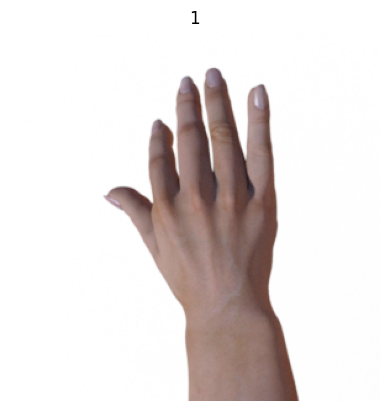

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


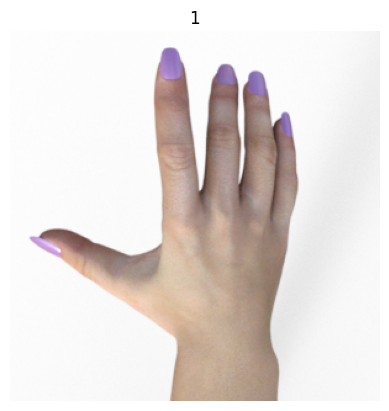

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


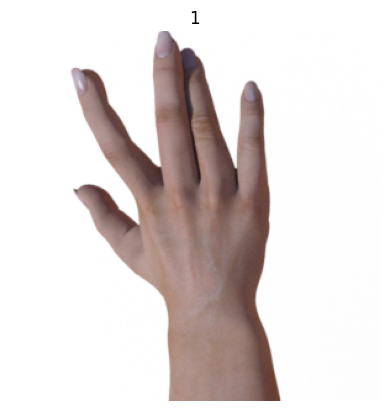

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


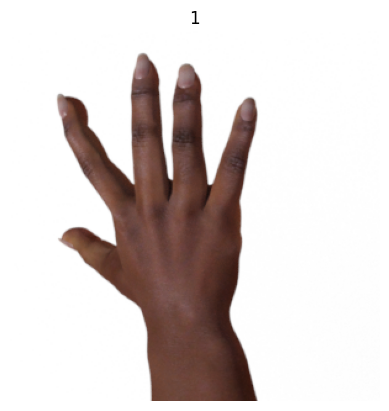

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


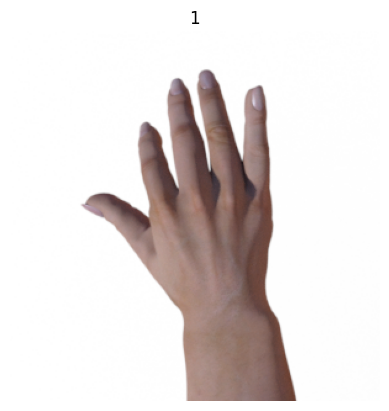

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


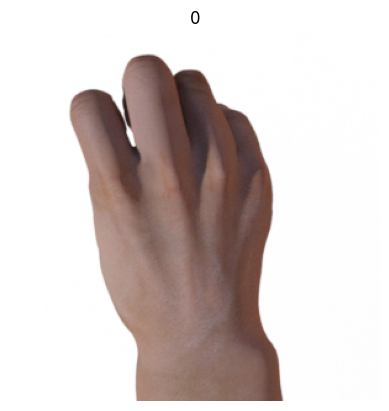

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


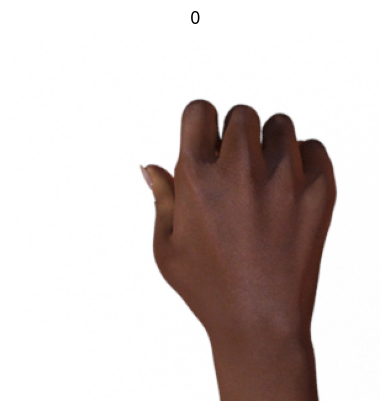

Input image shape: (300, 300, 3)
Image type: <dtype: 'uint8'>
Label shape: ()
Label type: <dtype: 'int64'>


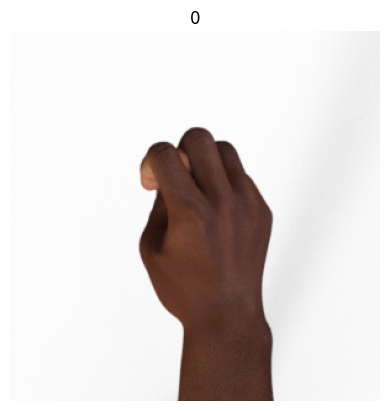

In [4]:
ds = dataset_train.take(8)  # Only take a single example
for example in ds:  # example is `('image': tf.Tensor, 'label': tf.Tensor)`
  image = example[0]
  label = example[1]
  print(f"Input image shape: {image.shape}\nImage type: {image.dtype}")
  print(f"Label shape: {label.shape}\nLabel type: {label.dtype}")
  plt.imshow(image, cmap='gray')
  plt.title(label.numpy())
  plt.axis("off")
  plt.show()


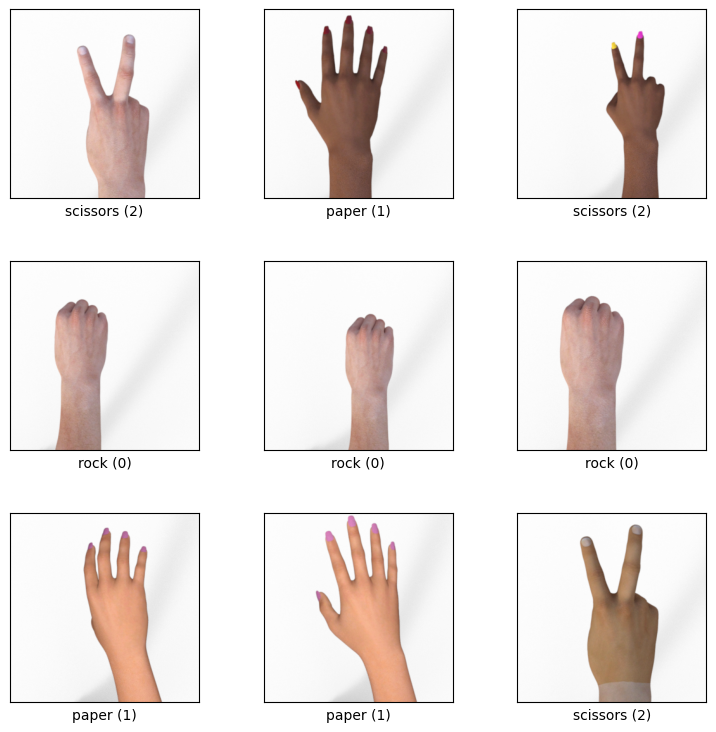

In [5]:
fig = tfds.show_examples(dataset_test, ds_info)

### Parameters

In [6]:
batch_size = 32
n_epochs = 8

### Preprocessing

In [7]:
# Preprocessing function
def preprocess(image, label):
  """applies the target preprocessing to the image and returns preprocessed image with label."""
  image = tf.image.resize(image, (32, 32))  # Resize images
  image = tf.image.rgb_to_grayscale(image)    # Convert to grayscale
  image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values
  return image, label


In [8]:
dataset_train = (dataset_train
                 .map(preprocess)
                 .shuffle(1000)
                 .batch(batch_size)
                 .prefetch(tf.data.AUTOTUNE))

dataset_val = (dataset_val
                .map(preprocess)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

dataset_test = (dataset_test
                .map(preprocess)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

## Training Neural Network

In [9]:
# Define the model architecture.
model = keras.Sequential([
    keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(16, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 8)         80        
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 8)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 16)        1168      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 16)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 32)          4640      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 32)          0

In [10]:
history = model.fit(
  dataset_train,
  validation_data=dataset_val,
  epochs=n_epochs
)


Epoch 1/8
71/71 [==============================] - 9s 41ms/step - loss: 0.9866 - accuracy: 0.5529 - val_loss: 0.7590 - val_accuracy: 0.7103
Epoch 2/8
71/71 [==============================] - 4s 31ms/step - loss: 0.5199 - accuracy: 0.8285 - val_loss: 0.2883 - val_accuracy: 0.9325
Epoch 3/8
71/71 [==============================] - 5s 41ms/step - loss: 0.2394 - accuracy: 0.9374 - val_loss: 0.1425 - val_accuracy: 0.9762
Epoch 4/8
71/71 [==============================] - 4s 31ms/step - loss: 0.1437 - accuracy: 0.9638 - val_loss: 0.0922 - val_accuracy: 0.9802
Epoch 5/8
71/71 [==============================] - 4s 31ms/step - loss: 0.0917 - accuracy: 0.9784 - val_loss: 0.0569 - val_accuracy: 0.9841
Epoch 6/8
71/71 [==============================] - 5s 45ms/step - loss: 0.0775 - accuracy: 0.9806 - val_loss: 0.0435 - val_accuracy: 0.9881
Epoch 7/8
71/71 [==============================] - 4s 31ms/step - loss: 0.0667 - accuracy: 0.9793 - val_loss: 0.0245 - val_accuracy: 0.9921
Epoch 8/8
71/71 [===

In [11]:
test_loss, baseline_accuracy = model.evaluate(
    dataset_test, verbose=0)

print(f'Test loss: {test_loss:.4f}')
print('Baseline test accuracy:', baseline_accuracy)

Test loss: 0.1924
Baseline test accuracy: 0.9220430254936218


In [12]:
# Saving the model in .h5 format
keras.models.save_model(model, './Full_Precision_RPS.h5', include_optimizer=False)


/tmp/ipykernel_3887/2839357759.py:2: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model, './Full_Precision_RPS.h5', include_optimizer=False)


In this notebook, we trained a convolutional neural network on the rock-paper-scissors dataset using TensorFlow (and various of its APIs). It's important to note the size of the trained model in terms of the number of trainable parameters and the baseline test accuracy for further comparisons during the pruning and quantization steps.

## Pruning
Experiment with different pruning methods available in tensorflow_model_optimization library and track the test set accuracy and model size.

### Task 1A: apply PolynomialDecay Pruning Schedule on the whole model.

### Task 1B: apply layerwise pruning only to the conv2D layers.

In [13]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow import keras
import numpy as np

loaded_model = keras.models.load_model('./Full_Precision_RPS.h5')

batch_size = 128
epochs = 15
num_train_samples = 10000

steps_per_epoch = np.ceil(num_train_samples / batch_size).astype(np.int32)

begin_step = steps_per_epoch * 2
end_step = steps_per_epoch * 10

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.00,
    final_sparsity=0.60,
    begin_step=begin_step,
    end_step=end_step
)

def apply_pruning_to_conv2d(layer):
    if isinstance(layer, keras.layers.Conv2D):
        return tfmot.sparsity.keras.prune_low_magnitude(layer, pruning_schedule=pruning_schedule)
    return layer

model_for_pruning = keras.models.clone_model(
    loaded_model,
    clone_function=apply_pruning_to_conv2d,
)

model_for_pruning.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_for_pruning.summary()

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
]

model_for_pruning.fit(
    dataset_train,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=dataset_test
)

model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

keras.models.save_model(model_for_export, './Pruned_Layerwise_Conv2D_RPS.h5', include_optimizer=False)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_conv2d  (None, 30, 30, 8)         154       
  (PruneLowMagnitude)                                            
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 8)         0         
 D)                                                              
                                                                 
 prune_low_magnitude_conv2d  (None, 13, 13, 16)        2322      
 _1 (PruneLowMagnitude)                                          
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 16)          0         
 g2D)                                                            
                                                                 
 prune_low_magnitude_conv2d  (None, 4, 4, 32)          9

/tmp/ipykernel_3887/3156082674.py:55: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model_for_export, './Pruned_Layerwise_Conv2D_RPS.h5', include_optimizer=False)


For both tasks try different sparsity parameters.

## Quantization
Quantization helps reduce the size and computation requirements of models, making them more efficient, especially for deployment on resource-constrained devices. Here, we only experiment with post-training quantization methods.

The following post-training quantization can be applied to both the base model and the pruned model. Note: all the following tasks will produce different versions of the same model.

### Task 2A: Dynamic Range Quantization

### Task 2B: Integer quantization of model parameters with float input/outputs (needs representative dataset)

### Task 2C: Full integer quantization (needs representative dataset)

In [14]:
import tensorflow as tf

def representative_data_gen():
  for images, labels in dataset_train.unbatch().batch(1).take(150):
    yield [images]

model_for_export = tf.keras.models.load_model('./Pruned_Layerwise_Conv2D_RPS.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

with open('Full_Integer_Quantized_RPS.tflite', 'wb') as f:
  f.write(tflite_model_quant)

print("Done")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Done


Verify each case with the following code:

In [15]:
interpreter = tf.lite.Interpreter(model_path="Full_Integer_Quantized_RPS.tflite")
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input type:", input_details[0]['dtype'])
print("Output type:", output_details[0]['dtype'])

Input type: <class 'numpy.int8'>
Output type: <class 'numpy.int8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Converting to tflite

Run the following bash command to convert the `your_model.tflite` to arduino (`C`) compatible format, a header file (`model.h`). Save the model for future use.

*Note: Remember to fix the paths.*

In [16]:
!echo "const unsigned char model[] = {" > finalModel_1B_2C.h
!cat Full_Integer_Quantized_RPS.tflite | xxd -i      >> finalModel_1B_2C.h
!echo "};"                              >> finalModel_1B_2C.h

You can check the file size of the final model header by executing the following code.

In [17]:
import os
model_h_size = os.path.getsize("finalModel_1B_2C.h") # Fix the path
print(f"Header file, model.h, is {model_h_size:,} bytes.")

Header file, model.h, is 105,558 bytes.
